## **OBJECTIF**

Votre mission est de développer un modèle de machine learning capable de prédire si un passager a survécu ou non au naufrage du Titanic, en vous basant sur diverses caractéristiques telles que l'âge, le sexe, la classe de billet, etc. Ce faisant, vous découvrirez des insights précieux sur les facteurs qui ont influencé la survie lors de cette tragédie historique.

Cette mission se base sur 2 grandes étapes et des sous étapes que voici :
- **ETAPE 1 : Préparation et exploration approfondie des données**  
      - 1.1 Chargement et préparation initiale des données  
      - 1.2 Analyse statistique descriptive  
      - 1.3 Visualisation approfondie des données  
      - 1.4 Analyse des valeurs manquantes  
- **ETAPE 2 : Préparation du modèle de régression logistique**  
      - 2.1 Sélection des features  
      - 2.2 Division des données  
      - 2.3 Préparation des features  
      - 2.4 Entraînement du modèle initial  
- **CONCLUSIONS**

---

## **1 : Préparation et exploration approfondie des données**

### **1.1 Chargement et préparation initiale des données**

Objectif : Charger le dataset et effectuer une première inspection des données.

Explication du code ci-dessous :

    Importer les bibliothèques nécessaires : pandas, numpy, matplotlib, seaborn.
    Charger les données du Titanic depuis le lien fourni avec pandas.
    Affichage des 10 premières lignes du DataFrame avec head().
    Utilisation de la méthode info() pour obtenir un aperçu global du DataFrame, y compris les types de données et les valeurs non-nulles.

In [4]:
# ========================================================
# 🛜 Imports des librairies
# ========================================================
# matplotlib et seaborn pour la visualisation graphique des données
import matplotlib.pyplot as plt
import seaborn as sns
# Pendant pour la gestion de lecture/ecriture de notre dataset sous format dataframe
import pandas as pd

In [5]:
# ========================================================
# 📊 Configuration du dataset
# ========================================================
# Ce dataset n'a servie qu'à comparer les deux jeux de données qui diffère légèrement au niveau des Series présentées 
# Le contenu des valeurs semble identiques sur les colonnes respectives
df_titanic_sns = sns.load_dataset('titanic')

# L'exercice demande spécifiquement de charger les donner depuis le lien fourni et avec la librairie pandas.
link = "https://raw.githubusercontent.com/murpi/wilddata/master/quests/titanic_passengers.csv"
df_titanic = pd.read_csv(link)
# Affichage des 10 premières lignes du DataFrame
df_titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [33]:
# ========================================================
# 📊 Aperçu global du DataFrame
# ========================================================
# la méthode .info() nous donnes les informations suivantes : 
    # Le label de chaque Série
    # le nombre de lignes et de colonnes de notre jeu de données
    # le nombre de valeurs non-nulles par colonnes
    # les types des valeurs de chaque colonne ainsi que leurs nombre
    # l'allocation mémoire de notre jeu de données
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


---
⁉️ **`Questions de réflexion :`** ⁉️

    Combien y a-t-il de passagers dans ce dataset ?

La méthode .info() montre un total de 891 entrées sur 12 colonnes.  
A première vue il y aurait 891 passagers dans ce dataset
    
    Quels types de données (numériques, catégorielles) pouvez-vous identifier ?

On peut identifier 3 types de données qu'elles soient numérique ou catégorielle.
5 de type `Int64`, 2 de type `float64` et 5 de type `str`
    
    Y a-t-il des colonnes avec des valeurs manquantes ? Si oui, lesquelles ?
Dans la partie `Non-Null Count` on peut identifier 3 colonnes qui n'ont pas pleinement la valeurs maximum.
Les colonnes `Age` `Cabin` et `Embarked` ont par conséquent des valeurs manquantes.

---

### **1.2 Analyse statistique descriptive**

Objectif : Obtenir des statistiques descriptives pour mieux comprendre la distribution des données.

Instructions :

    Analysez des statistiques descriptives des colonnes numériques.
    Pour les colonnes catégorielles, regardez la distribution des valeurs des catégories.
    Calculez le pourcentage global de survie.


In [34]:
# ========================================================
# 📊 Analyse des statistiques descriptives des colonnes numériques
# ========================================================
# La méthode .describe() nous donne les informations suivantes par Serie numérique
    # le nombre de valeurs (count)
    # la moyenne du total des valeurs (mean) qui peut être interprété comme un taux
    # l'écart type (std)
    # le minimum ainsi que le maximum (min - max)
    # les quartiles - le deuxième quartile (50%) représentant la médiane
df_titanic.select_dtypes('number').describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [35]:
# ========================================================
# 📊 Observation de la distribution des valeurs des catégories
# ========================================================
# la distribution des valeurs des catégories avec la méthode .describe() donne les informations suivantes :
    # le nombre de valeurs non-nulles (count)
    # le nombre de valeurs différentes
    # valeur la plus fréquente
    # nombre d'occurence de la valeur la plus fréquente
df_titanic.select_dtypes(include=['str']).describe()

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


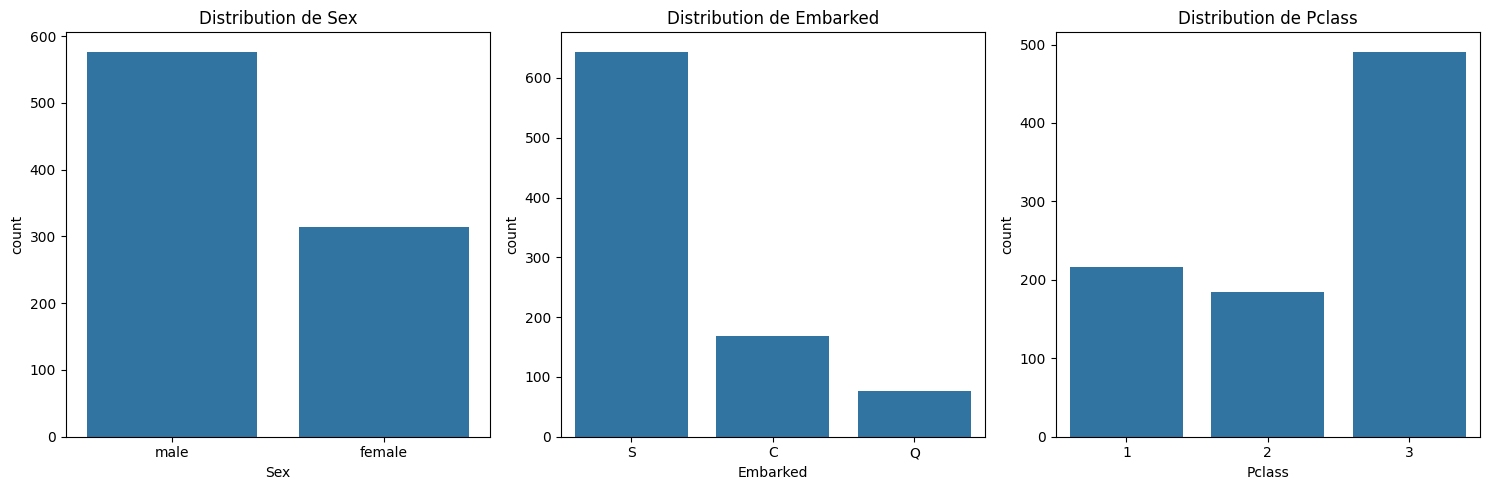

In [36]:
# ========================================================
# 📊 Observation de la distribution de certaines Series
# ========================================================
# Colonnes catégorielles à afficher - la Série Pclass donne des valeurs numérique, néanmoins elle est de nature catégorielle.
cols = ["Sex", "Embarked", "Pclass"]

# Création des sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boucle sur les colonnes
for ax, col in zip(axes, cols):
    sns.countplot(data=df_titanic, x=col, ax=ax)
    ax.set_title(f"Distribution de {col}")

plt.tight_layout()
# plt.show() # non necessaire dans jupyter notebook

In [44]:
# ========================================================
# 📊 Calcule du pourcentage global de survie
# ========================================================
# la méthode .value_counts(nomalize=True) nous donne le taux de chaque valeurs présente dans la Serie
# la méthode .mul() fait la multiplication du résulat pour obtenir une valeur sur 100
df_titanic['Survived'].value_counts(normalize=True).mul(100)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [45]:
# répartition des passagers entre les différentes classes
df_titanic["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

---
⁉️**`Questions de réflexion :`**⁉️

    Quelle est la moyenne d'âge des passagers ? Et la médiane ?
la moyenne d'âge des passagers est d'environ 29,6 ans.
la médiane d'âge des passagers est de 28 ans
    
    Quelle est la répartition des passagers entre les différentes classes ?
La répartition est la suivante :  
    - 491 passagers en 3ème classe  
    - 184 passagers en 2ème classe  
    - 216 passagers en 3ème classe  

    Y a-t-il une grande différence entre la moyenne et la médiane pour certaines variables ? Si oui, que cela pourrait-il indiquer ?
Il y a des différences significatives sur les colonnes **[Survived, Pclass, SibSp, Parch, Fare]**  
- Pour la colonne `Survived` les informations sont complémentaire. La médiane démontre une distribution où les non-survivants sont dominant. La moyenne montre un taux de survie d'environ 38%
- Pour la `Pclass` qui est établie avec des valeurs numériques mais reste néanmoins de nature catégorielle. La médiane une information sur la distribution où les passagers de la 3ème classe sont dominant. La moyenne ne donne pas d'informations signifactive.
- Pour les colonnes `SibSp` et `Parch` qui correspondent respectivement aux frères/Soeurs, Parents/enfants embarqué. Nous avoins une mediane à 0 ce qui signifie qu'au niveau de la distribution il y a plus de passagers qui ont embarqué seuls. Néanmoins le taux montré par la moyenne donne des information significatives qui pourrait indiqué que ceux qui ont embarqué avec frères/soeurs ou parents/enfant étaient des familles nombreuses. Un étude plus approfondie serait necessaire pour cet angle de recherche.
- Pour la colonne `Fare`, la différence sur le tarif des billets entre la mediane et la moyenne démontre qu'il pourrait y avoir des outliers qui tire la moyenne vers le haut.

---

### **1.3 Visualisation approfondie des données**

Objectif : Créer des visualisations pour mieux comprendre les relations entre les variables et leur impact sur la survie.

Instructions :

    Créez un histogramme de la distribution des âges, avec une distinction entre survivants et non-survivants.
    Réalisez un graphique en barres montrant le taux de survie par classe de passager.
    Faites un graphique en violon pour comparer la distribution des tarifs (Fare) entre les survivants et les non-survivants.
    Créez une heatmap de corrélation pour toutes les variables numériques.
    Réalisez un graphique en barres empilées pour montrer la survie en fonction du sexe et de la classe.


<Axes: xlabel='Age', ylabel='Count'>

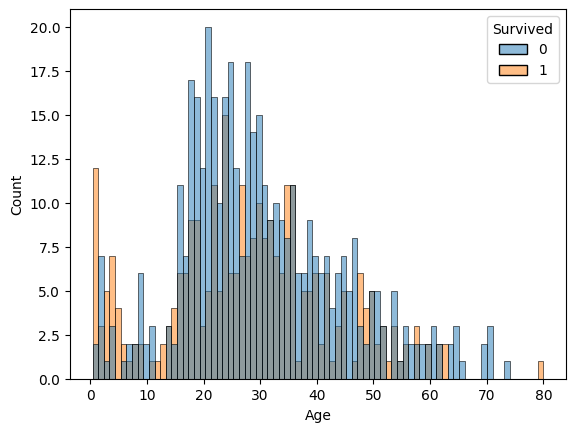

In [56]:
# ========================================================
# 📈 Histogramme de la distribution des âges, avec une distinction entre survivants et non-survivants
# ========================================================
sns.histplot(data = df_titanic, x = 'Age', hue = 'Survived', bins=80)

<Axes: xlabel='Survived'>

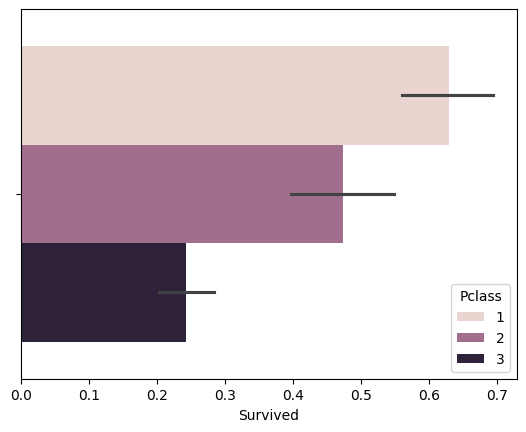

In [57]:
# ========================================================
# 📈 Graphique en barres montrant le taux de survie par classe de passager
# ========================================================
sns.barplot(data= df_titanic, x = 'Survived', hue = 'Pclass')

<Axes: xlabel='Fare'>

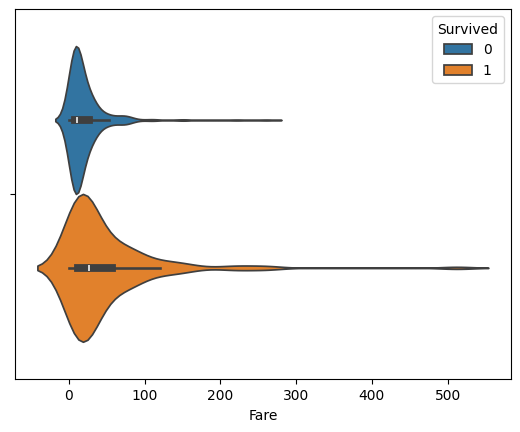

In [58]:
# ========================================================
# 📈 Graphique en violon pour comparer la distribution des tarifs (Fare) entre les survivants et les non-survivants
# ========================================================
sns.violinplot(data = df_titanic, x = 'Fare', hue='Survived')

<Axes: >

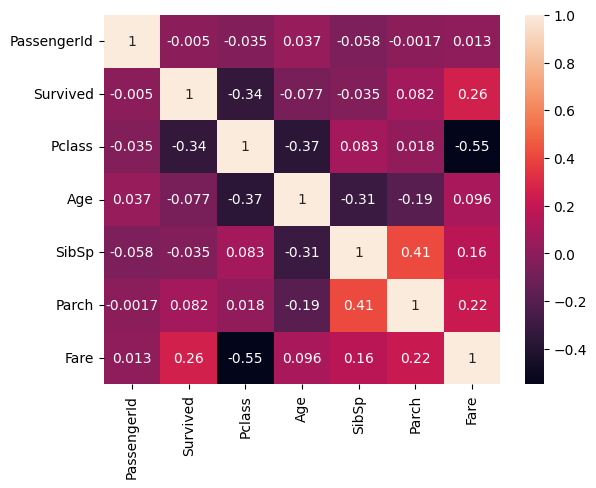

In [59]:
# ========================================================
# 📈 Heatmap de corrélation pour toutes les variables numériques
# ========================================================
sns.heatmap(data=df_titanic.select_dtypes('number').corr(method='pearson'),annot=True)

<Axes: xlabel='Sex', ylabel='Pclass'>

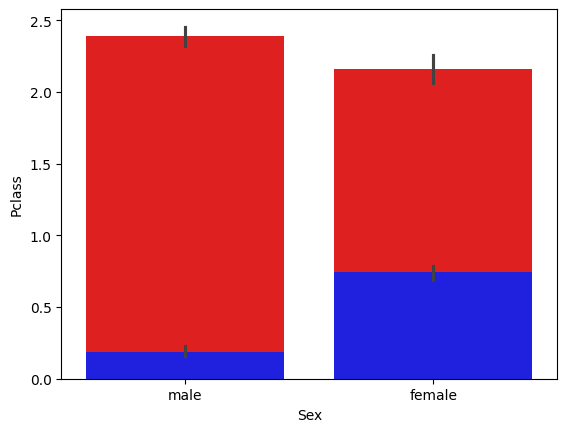

In [70]:
# ========================================================
# 📈 Graphiques en barres empilées pour montrer la survie en fonction du sexe et de la classe
# ========================================================
sns.barplot(x='Sex', y='Pclass' , data=df_titanic, color="red")
sns.barplot(x='Sex', y='Survived' , data=df_titanic, color = "blue")

---
⁉️**`Questions de réflexion :`**⁉️

    Y a-t-il une différence notable dans la distribution des âges entre les survivants et les non-survivants ?
Dans l'observation de l'histogramme de la distribution des âges, mise a part les enfants en bas âge, il n'y a pas de différence significative entre non survivants et survivant. L'âge ne semble pas être à lui seul un determinant dans le fait d'avoir survécue au naufrage.

    Quelle classe de passagers semble avoir eu le meilleur taux de survie ? Le pire ?
En observant le graphique en barres montrant le taux de survie par classe de passager, on peut voir une différence significatives entre passagers des différentes classes. Il faut mettre ce ci en relation avec le nombre de passager par classe. La nombre de passagers de la 3ème classe étant plus conséquente que les autres il est normal d'y avoir plus de non-survivants. Néanmoins la tendance entre les classes est réelle et le graphique montre un **taux** de survie qui est bien plus élévé chez les passsagers de 1ère classe.
    
    Pouvez-vous identifier une corrélation entre le prix du billet et les chances de survie ?
Il n'y a pas vraiment de corrélation direct entre le prix du billet et les chances de survie si ce n'est que le prix du billet est corrélé directement avec la classe. La classe montrant une tendance assez significatives sur le taux de survie, il est normal que même sans corrélation direct entre le prix du billet et la survie, il existe un lien indirect.

    Quelles variables semblent être les plus corrélées avec la survie ?
Il n'y a pas de variable significativement corrélé avec la survie mais il semble qu'il y ait un ensemble de variable qui pourrait jouer sur la survie ou non des passagers lors du naufrage.
je considère cet ensemble de variables suivant afin d'établie des une liste qui puisse ensemble etre bien corrélé à la survie : [Age, Sex, Pclass]. Pour aller plus en profondeur on pourrait tenter de voir si les familles nombreuses (Sibsp/Parch) de telle ou telle classe soit significativelment touché dans le fait de survivre ou non. 

---

### **1.4 Analyse des valeurs manquantes**

Objectif : Identifier et traiter les valeurs manquantes dans le dataset.

Instructions :

    Comptez les valeurs manquantes dans chaque colonne.
    Créez un graphique montrant le pourcentage de valeurs manquantes pour chaque colonne.
    Pour la colonne 'Age', analysez si les valeurs manquantes sont distribuées aléatoirement ou s'il y a un biais.
    Proposez et implémentez une stratégie pour gérer ces valeurs manquantes (par exemple, imputation par la moyenne, la médiane, ou une méthode plus avancée).


In [71]:
# ========================================================
# 📊 Décompte des valeurs manquantes de chaque colonne
# ========================================================
print(df_titanic.Age.isna().value_counts())
print("=================")
print(df_titanic.Age.isna().value_counts(normalize=True).mul(100))

Age
False    714
True     177
Name: count, dtype: int64
Age
False    80.13468
True     19.86532
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Pourcentage des valeurs nulles')

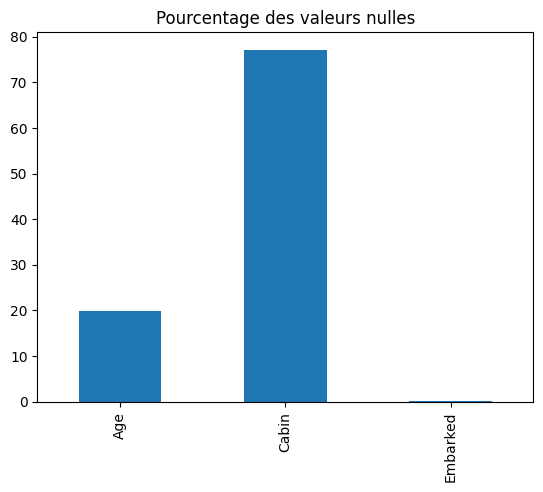

In [72]:
# ========================================================
# 📈 Graphique montrant le pourcentage de valeurs manquantes pour chaque colonne
# ========================================================
# On se concentre sur les colonnes qui ont des valeurs manquantes
df_titanic[["Age", "Cabin", "Embarked"]].isna().mean().mul(100).plot(kind='bar')
plt.title('Pourcentage des valeurs nulles')

In [73]:
# ========================================================
# 📊 Analyse comparatives des valeurs manquantes 
# ========================================================
# Ici nous cherchons à savoir s'il y a des biais entre différentes colonnes comparés aux valeurs manquantes dans [Age]
df_titanic["age_val_manquantes"] = df_titanic["Age"].isna()
liste_eval = ["Pclass", "Sex", "Survived"]
for i in liste_eval:
    print(df_titanic.groupby("age_val_manquantes")[i].value_counts(normalize=True).mul(100))
    print("=========================")

age_val_manquantes  Pclass
False               3         49.719888
                    1         26.050420
                    2         24.229692
True                3         76.836158
                    1         16.949153
                    2          6.214689
Name: proportion, dtype: float64
age_val_manquantes  Sex   
False               male      63.445378
                    female    36.554622
True                male      70.056497
                    female    29.943503
Name: proportion, dtype: float64
age_val_manquantes  Survived
False               0           59.383754
                    1           40.616246
True                0           70.621469
                    1           29.378531
Name: proportion, dtype: float64


In [ ]:
# ========================================================
# ⚠️ Stratégie pour gérer ces valeurs manquantes ⚠️ NON CHOISI
# ======================================================== 
# L'autre stratégie aurait été de changer les valeurs en utilisant du machine learning sur les 
# L'idée aurait de prédire l'age des passagers est intéressante néanmoins cela reste des valeurs fictives 

In [12]:
# ========================================================
# ⚠️ Imports des librairies ⚠️ NON CHOISI
# ======================================================== 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Copie du dataframe original
df = df_titanic.copy()

# Encodage simple
df["Sex"] = LabelEncoder().fit_transform(df["Sex"])

# Variables utilisées pour les features
features = ["Pclass", "Sex", "SibSp", "Parch", "Fare"]

# Séparation pour l'entrainement
train_df = df[df["Age"].notnull()]
test_df = df[df["Age"].isnull()]

X_train = train_df[features]
y_train = train_df["Age"]

X_test = test_df[features]

# Modèle + hyperparamètres
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Prédiction des âges manquants
predicted_ages = model.predict(X_test)

# Remplacement
df.loc[df["Age"].isnull(), "Age"] = predicted_ages

In [16]:
# ========================================================
# ⚠️ Vérification des différences ⚠️ NON CHOISI
# ======================================================== 
# On peut observer qu'avec le machine learning les valeurs de la médiane ainsi que le min et max sont  identiques.
# On retrouve des différences légères sur la moyenne le 1er et 3ème quartile ainsi que l'écart type.
# Cette stratégie est à tester au niveau de l'apprentissage afin de voir s'il y a des différences.
new_df = pd.concat([df['Age'],df_titanic['Age']],axis=1)
new_df.describe()

,Age,Age
count,891.000000,714.000000
mean,29.607075,29.699118
std,13.684888,14.526497
min,0.420000,0.420000
25%,21.000000,20.125000
50%,28.000000,28.000000
75%,37.000000,38.000000
max,80.000000,80.000000


In [74]:
# ========================================================
# 📊 Stratégie choisi pour gérer les valeurs manquantes
# ========================================================

# L'analyse comparatives des valeurs manquantes démontre des biais de l'âge entre la classe, le genre et le taux de survie
# On observe que
    # le taux de valeurs manquantes entre le genre, la survie pour l'âge des passagers sont quasi similaire
    # le taux de valeurs manquantes entre les genre est assez conséquent
    # le taux de valeurs manquantes entre les survivants est assez conséquent
    # la comparaisons avec la classe est fortement biaisées. Les taux sont trop différents 
    # Le remplacement par machine learning serait une bonne solution mais qui n'est toujours pas la réalité même si on s'en rapproche

# Il y aurait donc deux stratégies qui pourraient être viable. 

    # 1ère stratégie : Remplacer les valeurs manquantes
        # La moyenne et la mediane de l'âge n'ont pas de grandes différences donc l'un ou l'autre reste un bon choix
        # Cependant on doit changer les valeurs en faisant attention à la distribution des valeurs manquantes comparé à la classe
        # Bien que les valeurs trouvé avec le machine learning ait été concluant, le fait de dénaturé le dataset n'est pas mon choix

    # 2ème stratégie : Supprimer les valeurs manquantes
        # Supprimer les valeurs manquantes ne dénaturerai pas les valeurs avec des valeurs qui ne sont pas la réalité 
        # Néanmoins la suppression des valeurs retirerai des informations et offrirai un jeu de données plus petit

# La stratégie adoptée est la suppression des lignes où se trouve des valeurs manquantes 

---
**`Questions de réflexion :`**

    Quelles colonnes ont le plus de valeurs manquantes ?
Les colonnes qui ont le plus de valeurs manquantes sont les colonnes [Age, Cabin].  

     Pourquoi certaines colonnes pourraient-elles avoir plus de valeurs manquantes que d'autres ?
- Pour la colonne 'Cabin' il se pourrait que les valeurs manquantes soit du fait que les passagers n'avait pas tous une cabine attitrés. Il se pourrait que les cabines n'ait été alloué qu'au personnes ayant achetés des billets tarifs élevés. Il se pourrait que les informations n'ait juste pas été noté. Beaucoup de supposition mérite une analyse plus détaillé sur cet angle de vue.
- Pour la colonne 'Age' il se pourrait qu'à cette époque l'age n'ait pas été mentionné lors de l'embarquement. 

      Quelle stratégie d'imputation vous semble la plus appropriée pour chaque colonne avec des valeurs manquantes ? Pourquoi ?
Je n'observe pas de valeurs numériques en elles mêmes qui soit suffisament corrélé à la survie pour que l'on ne puisse pas s'en passé. La variable qui offre le plus de corrélation semble être le "Sex".  
Bien que la moyenne et la mediane ne montre pas de outlier conséquent je prend le partie de résté sur des valeurs réalistes avec un dataset plus petit mais sans ambiguités au niveau des valeurs.
Ma stratégie sera donc la suppression des valeurs manquantes sans essayer de les remplacer.

---

## **2 : Préparation du modèle de régression logistique**

### **2.1 Sélection des features**

Instructions :

Divisez les données en features (X) et target (y).

In [102]:
# ========================================================
# 💾 Division des données en feature(s) et target
# ========================================================
# Sélection des features à partir de l'exploration approfondie des données les plus pertinentes 
# Nous allons chercher à savoir quels type de personnes aurait survécu en fonction de l'âge, du genre et de la classe.
# Nous suivons la stratégie de suppression des valeurs manquantes avec la méthode .dropna() sur les lignes (axis=0)
data = df_titanic[["Pclass", "Survived", "Sex", "Age"]].dropna(axis=0)

# Sélection des features (X) et de la target (y)
X = data[['Pclass', 'Sex', 'Age']]
y = data[['Survived']] 

### **2.2 Division des données**

Objectif : Diviser les données en ensembles d'entraînement et de test.

Instructions :

    Importez train_test_split de sklearn.
    Divisez vos données en ensembles d'entraînement et de test (80% train, 20% test).
    Utilisez random_state=36 pour la reproductibilité.
    Utilisez `stratify = y' pour vous assurer que la porportion de survivants est similaire dans les deux ensembles.
    Vérifiez que la proportion de survivants est similaire dans les deux ensembles.


In [120]:
# ========================================================
# 🛜 Importation train_test_split de sklearn.
# ========================================================
# librairie pour diviser notre ensemble de données en sous-ensembles d'entraînement et de test,
from sklearn.model_selection import train_test_split

In [121]:
# ========================================================
# 💾 Configuration de la division des données
# ========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # division 80/20 pour le test
    random_state=36,     # reproductibilité à 36
    stratify = y         # proportion sur la target
)

In [122]:
# ========================================================
# 💾 Vérification de la proportion dans les ensembles
# ========================================================
print("=== Proportion de survivants ===")
print(f"Total  : {y.value_counts(normalize=True)[1]:.2%}")
print(f"Train  : {y_train.value_counts(normalize=True)[1]:.2%}")
print(f"Test   : {y_test.value_counts(normalize=True)[1]:.2%}")

=== Proportion de survivants ===
Total  : 40.62%
Train  : 40.63%
Test   : 40.56%


---
⁉️**`Questions de réflexion :`**⁉️

    Pourquoi est-il important de diviser les données en ensembles d'entraînement et de test ?
Il est important de diviser les ensembles afin de garder une objectivité des résultats de notre modèle. Ainsi on évite le sur-apprentissage et le sous apprentissage.  

    Que se passerait-il si la proportion de survivants était très différente entre les deux ensembles ?
Si la proportion de survivants était mal réparti entre les ensembles d'entraînement et de test, cela donnerait des ensembles de données déséquilibrés

---

### **2.3 Préparation des features**

Objectif : Préparer les données pour l'entraînement du modèle.

Instructions :

    Utilisez OneHotEncoder() pour encoder les variables catégorielles.
    Normalisez les features numériques en utilisant StandardScaler de sklearn.


In [139]:
# ========================================================
# 🛜 Imports et configuration 
# ========================================================
# librairie qui sert à encoder les variables catégorielle en numérique avec compression
from sklearn.preprocessing import OneHotEncoder
# librairie qui sert à standardiser les valeurs des colonnes numérique 
from sklearn.preprocessing import StandardScaler
import numpy as np

encodage = OneHotEncoder(sparse_output=False) # sparse_output=False pour évité la compression des 0 dans les données.
scaler = StandardScaler()

In [140]:
# ========================================================
# ↔️ Séparation des colonnes numériques et catégorielles.
# ========================================================
Xnum = X[['Pclass', 'Age']]               # Xnum -> données numériques
Xtrain_num = X_train[['Pclass', 'Age']]   # Xtrainnum -> données numériques d'entrainement
Xtest_num = X_test[['Pclass', 'Age']]     # Xtestnum -> données numériques de test

Xcat = X[['Sex']]                         # Xcat -> données catégorielle
Xtrain_cat = X_train[['Sex']]             # Xtrain_cat -> données catégorielle d'entrainement
Xtest_cat = X_test[['Sex']]               # Xtest_cat -> données catégorielle de test

In [141]:
# ========================================================
# 💾 Encodage des features catégorielles
# ========================================================
# On créer de nouveau DataFrame pour pouvoir concaténer tous les nouveau jeu de données 
Xcat_norm = pd.DataFrame(encodage.fit_transform(Xcat),columns=['SexF', 'SexM'])
Xtrain_cat_norm = pd.DataFrame(encodage.fit_transform(Xtrain_cat),columns=['SexF', 'SexM'])
Xtest_cat_norm = pd.DataFrame(encodage.fit_transform(Xtest_cat),columns=['SexF', 'SexM'])

In [142]:
# ========================================================
# 💾 Normalisation des features numériques
# ========================================================
# On créer de nouveau DataFrame pour pouvoir concaténer tous les nouveau jeu de données 
Xnum_norm = pd.DataFrame(scaler.fit_transform(Xnum),columns=['Pclass', 'Age'])
Xtrain_num_norm = pd.DataFrame(scaler.fit_transform(Xtrain_num),columns=['Pclass', 'Age'])
Xtest_num_norm = pd.DataFrame(scaler.fit_transform(Xtest_num),columns=['Pclass', 'Age'])

In [143]:
# ========================================================
# 📦️ Concaténation des datasets
# ========================================================
XML = pd.concat([Xnum_norm,Xcat_norm],axis=1)
XML_train = pd.concat([Xtrain_num_norm,Xtrain_cat_norm],axis=1)
XML_test = pd.concat([Xtest_num_norm,Xtest_cat_norm],axis=1)

---
⁉️**`Questions de réflexion :`**⁉️

    Pourquoi est-il important d'encoder les variables catégorielles ?
Le modèle ne pourrait pas interprété des valeurs de texte donc on doit impérativement les encodé de manière numérique

    Quels sont les avantages de la normalisation des features numériques ?
La normalisation garde les distance entre les valeurs dans une plage numérique plus petites ce qui facilite le travail du modèle et centralise les valeurs sur une même échelle.
    
    Y a-t-il des features que vous avez décidé de ne pas inclure ? Pourquoi ?
Les feature qui n'ont pas été incluses sont celles qui après exploration et analyse des données parraissient non pertinentes pour l'entrainement du modèle. Soit parce que celle-ci ne démontrait pas de corrélation suffisante ou bien n'offrait pas de données satisfaisante pour l'objectif.

---

### **2.4 Entraînement du modèle initial**

Objectif : Entraîner un premier modèle de régression logistique et évaluer ses performances.

Instructions :

    Importez LogisticRegression de sklearn.
    Instanciez un modèle de régression logistique avec random_state=36.
    Entraînez le modèle sur les données d'entraînement.
    Faites des prédictions sur les ensembles d'entraînement et de test.
    Calculez et affichez la précision (accuracy) sur les deux ensembles.
    Affichez la matrice de confusion et le rapport de classification pour l'ensemble de test.
    Affichez les coefficients du modèle et interprétez-les.


In [144]:
# ========================================================
# 🛜 Imports et configuration 
# ========================================================
# Création et entrainement d'un modèle de régression logistique
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Configuration du modèle avec random_state=36
model = LogisticRegression(random_state=36,)

In [145]:
# Le modele donne un message d'erreur
# Le modèle attend un vecteur et non pas une matrice. on utilise donc la méthode .ravel() conseiller par le message d'erreur
y_train = np.array(y_train).ravel()

In [146]:
# ========================================================
# 💾 Entrainement des données sur le modèle 
# ========================================================
# Calcule des prédictions sur les données de test
model.fit(XML_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",36
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [147]:
# ========================================================
# 💻️ Prédictions sur les ensembles d'entraînement et de test.
# ========================================================
y_pred_train = model.predict(XML_train)
y_pred_test  = model.predict(XML_test)

In [149]:
# ========================================================
# 💻️ Précision (accuracy) sur les deux ensembles.
# ========================================================
print(f"Précision Train : {accuracy_score(y_train, y_pred_train):.2%}")
print(f"Précision Test  : {accuracy_score(y_test, y_pred_test):.2%}")

Précision Train : 77.58%
Précision Test  : 85.31%


In [154]:
# ========================================================
# 💻️ Matrice de confusion 
# ========================================================
print(confusion_matrix(y_test, y_pred_test))

[[71 14]
 [ 7 51]]


In [153]:
# ========================================================
# 💻️ Rapport de classification
# ========================================================
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.91      0.84      0.87        85
           1       0.78      0.88      0.83        58

    accuracy                           0.85       143
   macro avg       0.85      0.86      0.85       143
weighted avg       0.86      0.85      0.85       143



In [189]:
# ========================================================
# 💻️ Coefficients du modèle
# ========================================================
# liste des features dans l'ordre du dataset
feature_names = ['Pclass', 'Age', 'SexF', 'SexM']

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(f"Intercept : {model.intercept_[0]:.4f}\n")
print(coef_df.to_string(index=False))

Intercept : -0.0954

Feature  Coefficient
   SexF     1.099732
    Age    -0.477936
 Pclass    -0.940549
   SexM    -1.185123


---
⁉️**`Questions de réflexion :`**⁉️

    Comment interprétez-vous la différence de précision entre l'ensemble d'entraînement et l'ensemble de test ?
Le modèle obtient 77.76% sur le train et 84.62% sur le test, soit une différence d'environ 7 points en faveur du test.   
L'ensemble de test supérieur indique simplement que le modèle à eu plus de facilité de prédiction. Il faudrait probablement essayer avec des hyperparamètre différent
    
    Quelles features semblent avoir le plus d'impact sur la prédiction selon les coefficients du modèle ?
En se basant sur la valeur des coefficients des variable SexM et SexF. Le sexe est de loin la feature dominante, ce qui est cohérent avec la politique "les femmes et les enfants d'abord".

    Y a-t-il des signes de surapprentissage (overfitting) ou de sous-apprentissage (underfitting) ?
- Pas de sur-apprentissage — il y aurait overfitting si le train était très élevé (ex: 95%) et le test beaucoup plus bas (ex: 70%). Ici l'écart est faible et inversé

- Pas de sous-apprentissage — il y aurait underfitting si les deux scores étaient mauvais (ex: 60%/62%). Ici ~80% sur les deux est satisfaisant pour une régression logistique avec seulement 3 features
---

## **Conclusion**

📑 Résumez les principales découvertes de votre analyse. 📑
    
    Quels facteurs semblent avoir le plus influencé la survie sur le Titanic ?
Le facteur d'influence le plus marquant est clairement le genre des passagers. Que ce soit lors de l'exploration et la visualisation des données ou dans le résultat du modèle de regresssion linéaire, la variable "Sex" est celle qui démontre la plus grande corrélation sur la survie ou non des passgers lors du naufrage. Ensuite viens la classe non pas de manière dominante mais le fait d'avoir appartenue à la première classe grandi significativement le taux de survie.
    
    Quelles sont les limites de votre analyse et comment pourriez-vous l'améliorer ?
Malgré un bon score de prédiction certains facteur pourrait néanmoins amélioré les résultat. 
Nous pourrions utilisé plus de variables. Seulement trois ici ont été utilisé. On pourraient ajouté le Sibsp et le Parch ou autres.  
Lors de l'utilisation du train_test_split la variable d'évaluation n'a pas été utilisé, cela pourrait affiné le modèle.  
L'amélioration pourrait également se situé sur les hyperparamètres qui n'ont pas été réellement évalués.  
La comparaison avec d'autre modèle pourrait faire évoluer les résultats

    Si vous deviez conseiller quelqu'un pour augmenter ses chances de survie sur le Titanic, que lui diriez-vous basé sur votre analyse ?
Cette question n'a pas de sens puisque les enjeux pour la survie ne sont pas portés sur des changements possible. Conseiller à quelqu'un de changer de genre ou de devenir plus riche et/ou de se payer une 1ère classe ne sont pas des conseils logique hors simulation.

    Comment les techniques que vous avez apprises dans ce projet pourraient-elles être appliquées à d'autres problèmes de la vie réelle ?
Les techniques d'études et d'analyses de base de données ainqi que kl'entrainement de modèle prédictif de classification comme la regression linéaire que nous avons utilisé dans ce projet pour évolué sur d'autre projet tel que la classification de mail (Spam/NonSpam).  
Le modèle de regression linéaire semble apporté une réponse binaire.

